# Processamento de Sinais II — Lista 1
Solução usando operações básicas do OpenCV.

Execute as células na ordem. O dataset fica na pasta compartilhada `data/` do repositório.

In [1]:
from pathlib import Path
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Funciona executando daqui (lista_1/) ou da raiz do repo.
HERE = Path.cwd()
REPO = HERE if (HERE / 'data').exists() else HERE.parent
DATA = REPO / 'data' / 'dataset'
ZIP = REPO / 'data' / 'dataset.zip'
if not DATA.exists():
    with zipfile.ZipFile(ZIP) as arquivo: arquivo.extractall(REPO / 'data')

def ler(nome, cinza=False):
    modo = cv2.IMREAD_GRAYSCALE if cinza else cv2.IMREAD_COLOR
    imagem = cv2.imread(str(DATA / nome), modo)
    if imagem is None: raise FileNotFoundError(nome)
    return imagem

def mostrar(imagens, colunas=4, tamanho=(4, 4)):
    linhas = int(np.ceil(len(imagens) / colunas))
    fig, axs = plt.subplots(linhas, colunas, figsize=(tamanho[0]*colunas, tamanho[1]*linhas), squeeze=False)
    axs = axs.ravel()
    for ax, (titulo, imagem) in zip(axs, imagens):
        if imagem.ndim == 3: imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
        ax.imshow(imagem, cmap='gray')
        ax.set_title(titulo); ax.axis('off')
    for ax in axs[len(imagens):]: ax.axis('off')
    plt.tight_layout(); plt.show()

lena = ler('lena2.tif', True)
lena_colorida = ler('lena3.tif')
frog = ler('frog.tif', True)
brain = ler('brain.jpg', True)
print('Dataset:', DATA)

Dataset: C:\Users\pedro\OneDrive - cefet-rj.br\Documentos\Faculdade\processamento de sinais 2\Processamento-de-Sinais-2\data\dataset


## 1) Redução da Lena gray
A interpolação `INTER_AREA` é apropriada para reduzir imagens porque faz uma média dos pixels.

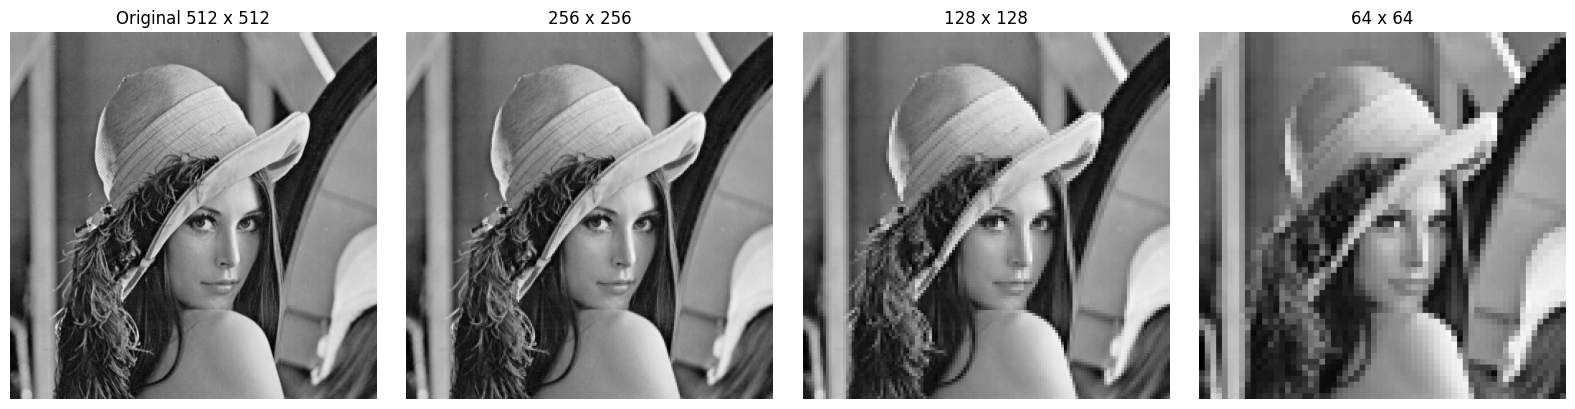

Ao reduzir, detalhes finos são perdidos e a imagem fica mais suave.


In [2]:
reduzidas = []
for lado in [256, 128, 64]:
    pequena = cv2.resize(lena, (lado, lado), interpolation=cv2.INTER_AREA)
    de_volta = cv2.resize(pequena, (512, 512), interpolation=cv2.INTER_NEAREST)
    reduzidas.append((f'{lado} x {lado}', de_volta))
mostrar([('Original 512 x 512', lena)] + reduzidas)
print('Ao reduzir, detalhes finos são perdidos e a imagem fica mais suave.')

## 2) Canais da Lena color
Cada canal é uma imagem de intensidade. Por isso podemos visualizar R, G e B em níveis de cinza.

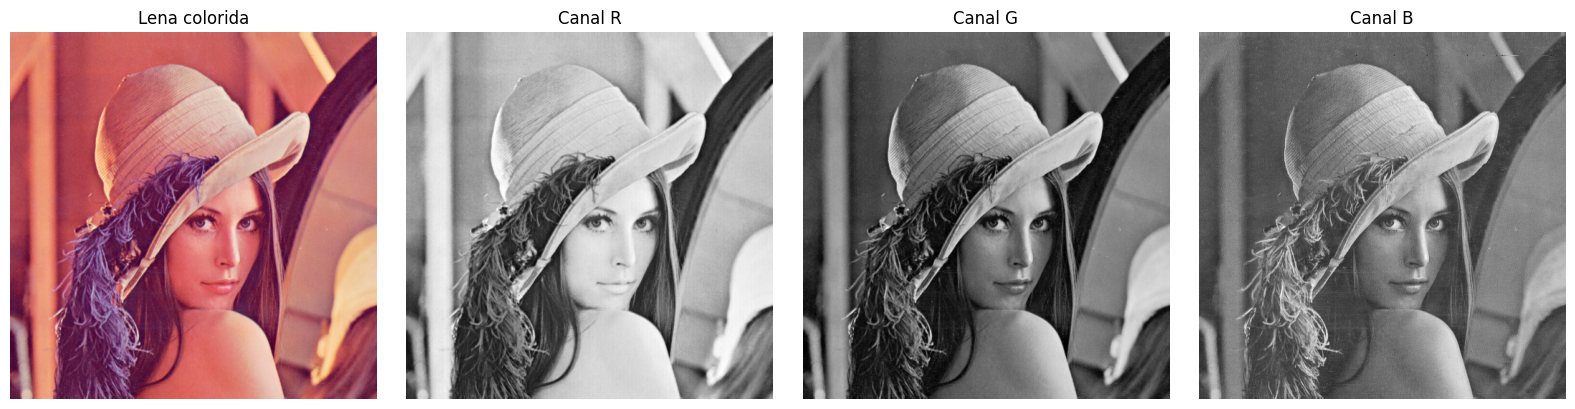

In [3]:
b, g, r = cv2.split(lena_colorida)
mostrar([('Lena colorida', lena_colorida), ('Canal R', r), ('Canal G', g), ('Canal B', b)])

## 3) Bits por pixel e quantização
RGB usa 8 bits em cada um dos três canais: 24 bpp. A imagem cinza usa 8 bpp. Com menos bits, aparecem regiões com o mesmo tom (banding).

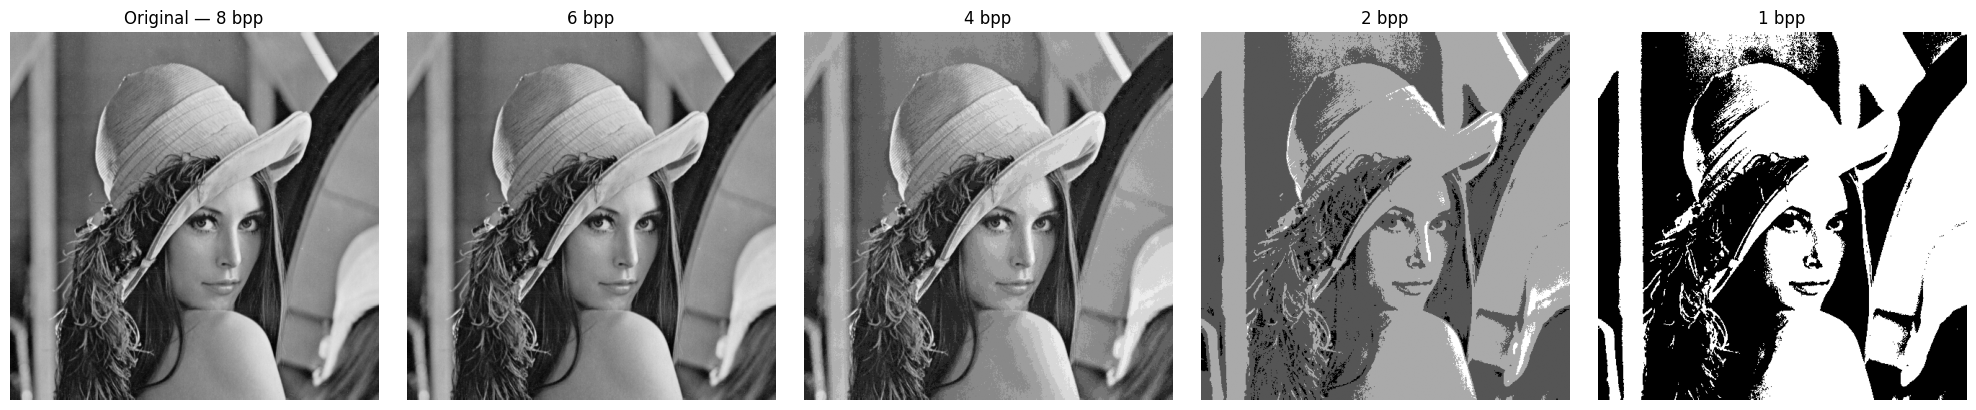

A quantidade de níveis é 2^bits: 64, 16, 4 e 2 níveis.


In [4]:
def quantizar(imagem, bits):
    niveis = 2 ** bits
    passo = 255 / (niveis - 1)
    return np.uint8(np.round(imagem / passo) * passo)
mostrar([('Original — 8 bpp', lena)] + [(f'{bits} bpp', quantizar(lena, bits)) for bits in [6, 4, 2, 1]], colunas=5)
print('A quantidade de níveis é 2^bits: 64, 16, 4 e 2 níveis.')

## 4) Quadrado central e percepção de brilho
A diferença de brilho é percebida em relação ao fundo. A resposta visual humana é aproximadamente logarítmica, então diferenças relativas costumam ser mais importantes que diferenças absolutas.

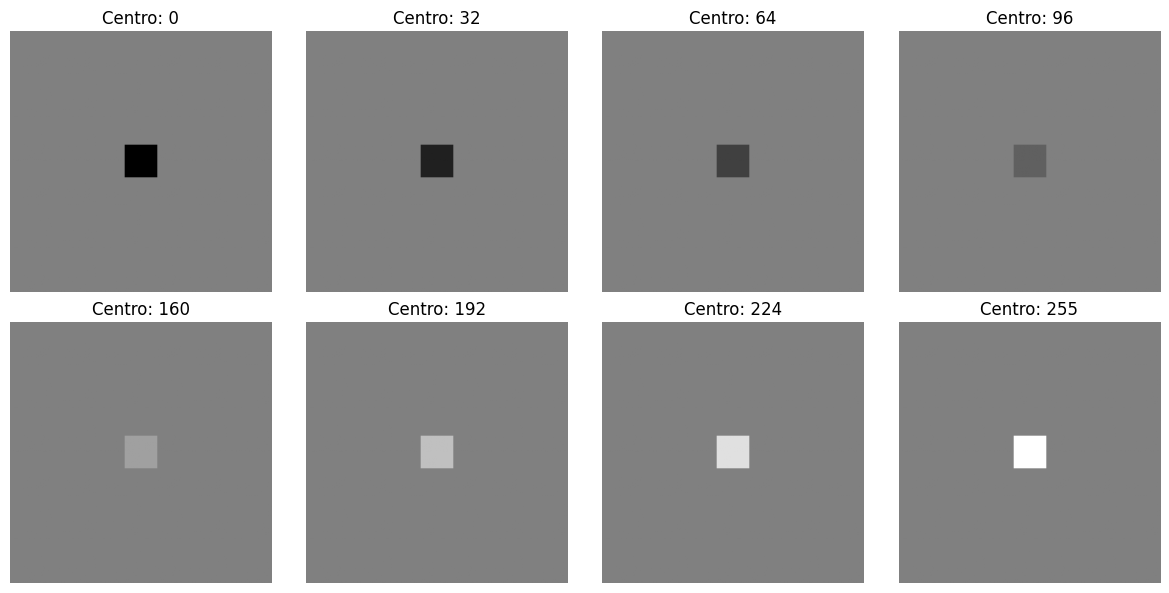

Perto do nível do fundo, o quadrado fica pouco perceptível.


In [5]:
fundo = np.full((256, 256), 128, np.uint8)
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for ax, valor in zip(axs[0], [0, 32, 64, 96]):
    imagem = fundo.copy(); imagem[112:144, 112:144] = valor
    ax.imshow(imagem, cmap='gray', vmin=0, vmax=255); ax.set_title(f'Centro: {valor}'); ax.axis('off')
for ax, valor in zip(axs[1], [160, 192, 224, 255]):
    imagem = fundo.copy(); imagem[112:144, 112:144] = valor
    ax.imshow(imagem, cmap='gray', vmin=0, vmax=255); ax.set_title(f'Centro: {valor}'); ax.axis('off')
plt.tight_layout(); plt.show()
print('Perto do nível do fundo, o quadrado fica pouco perceptível.')

## 5) Ajuste de brilho
O fator 1,2 aumenta as intensidades. O limite 255 causa saturação nos pixels que já eram claros.

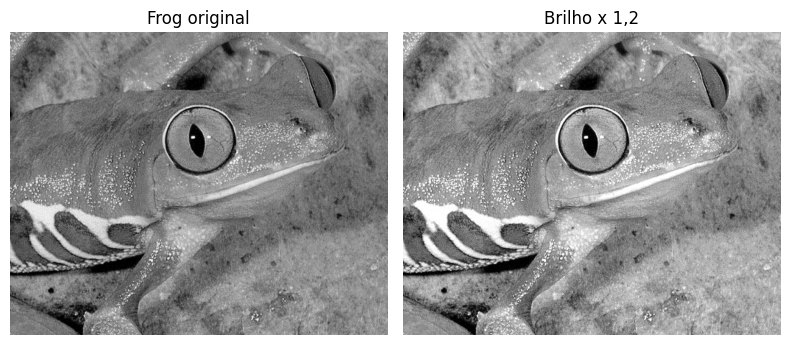

In [6]:
brilho = cv2.convertScaleAbs(frog, alpha=1.2, beta=0)
mostrar([('Frog original', frog), ('Brilho x 1,2', brilho)], colunas=2)

## 6) Ajuste de contraste com gamma = 1,5
Aqui usamos `saida = entrada ** gamma`. Como gamma é maior que 1, os tons médios ficam mais escuros.

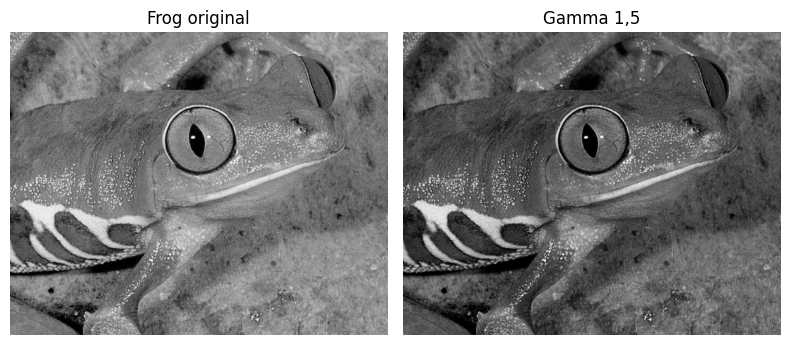

In [7]:
tabela = np.array([((i / 255.0) ** 1.5) * 255 for i in range(256)], dtype=np.uint8)
gamma = cv2.LUT(frog, tabela)
mostrar([('Frog original', frog), ('Gamma 1,5', gamma)], colunas=2)

## 7) Redução de ruído pela média
O ruído aleatório tende a se cancelar quando calculamos a média de várias imagens.

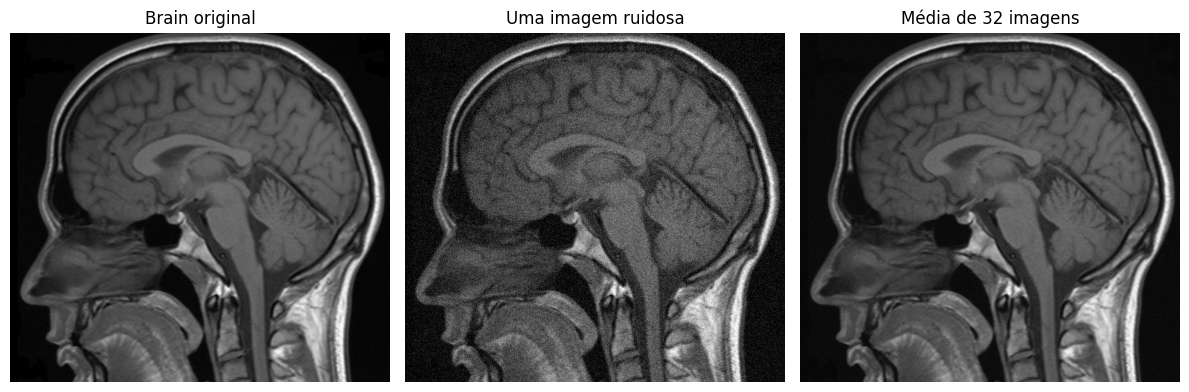

A média fica mais próxima da imagem original e reduz o ruído.


In [8]:
np.random.seed(7)
imagens_ruidosas = []
for _ in range(32):
    ruido = np.random.normal(0, 25, brain.shape)
    imagens_ruidosas.append(np.clip(brain.astype(float) + ruido, 0, 255))
media = np.uint8(np.mean(imagens_ruidosas, axis=0))
mostrar([('Brain original', brain), ('Uma imagem ruidosa', np.uint8(imagens_ruidosas[0])), ('Média de 32 imagens', media)], colunas=3)
print('A média fica mais próxima da imagem original e reduz o ruído.')

## 8) Histogramas
Um histograma concentrado indica uma faixa pequena de intensidades. Um histograma espalhado indica maior contraste.

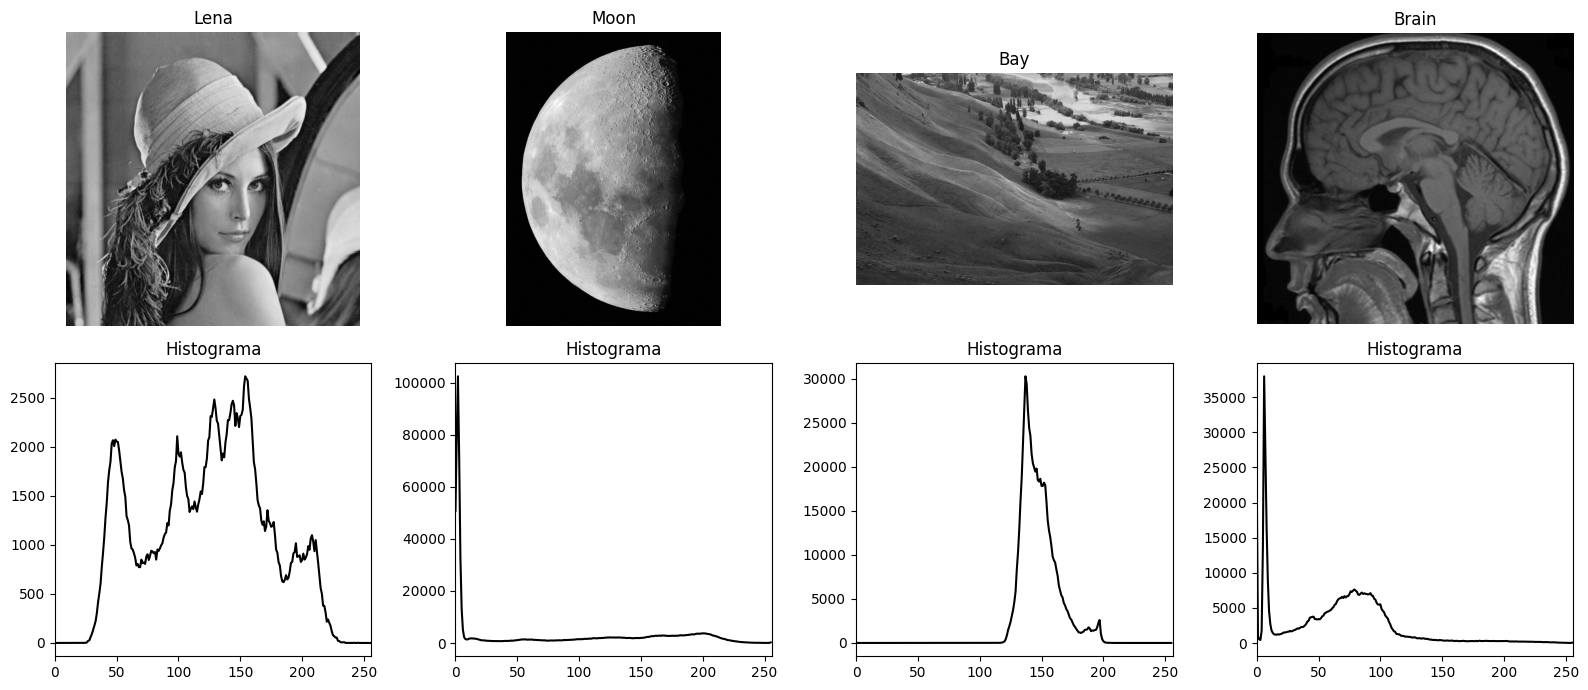

In [9]:
imagens = {'Lena': lena, 'Moon': ler('moon.jpg', True), 'Bay': ler('bay.jpg', True), 'Brain': brain}
fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for coluna, (nome, imagem) in enumerate(imagens.items()):
    axs[0, coluna].imshow(imagem, cmap='gray'); axs[0, coluna].set_title(nome); axs[0, coluna].axis('off')
    hist = cv2.calcHist([imagem], [0], None, [256], [0, 256])
    axs[1, coluna].plot(hist, color='black'); axs[1, coluna].set_xlim(0, 256); axs[1, coluna].set_title('Histograma')
plt.tight_layout(); plt.show()

## 9 e 10) Equalização global e adaptativa
A equalização global usa o histograma inteiro. A CLAHE divide a imagem em blocos e limita o aumento de contraste para não exagerar o ruído.

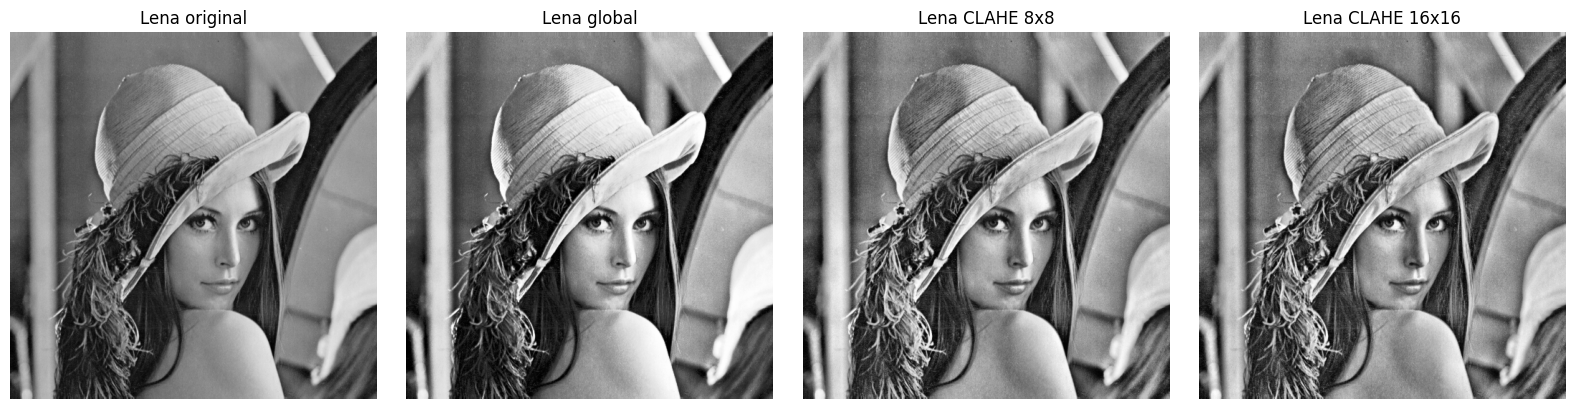

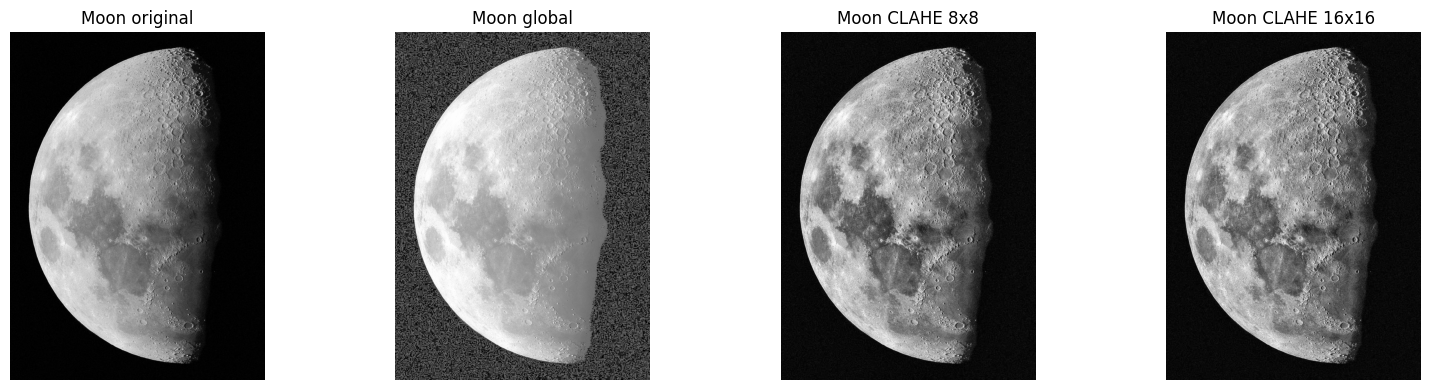

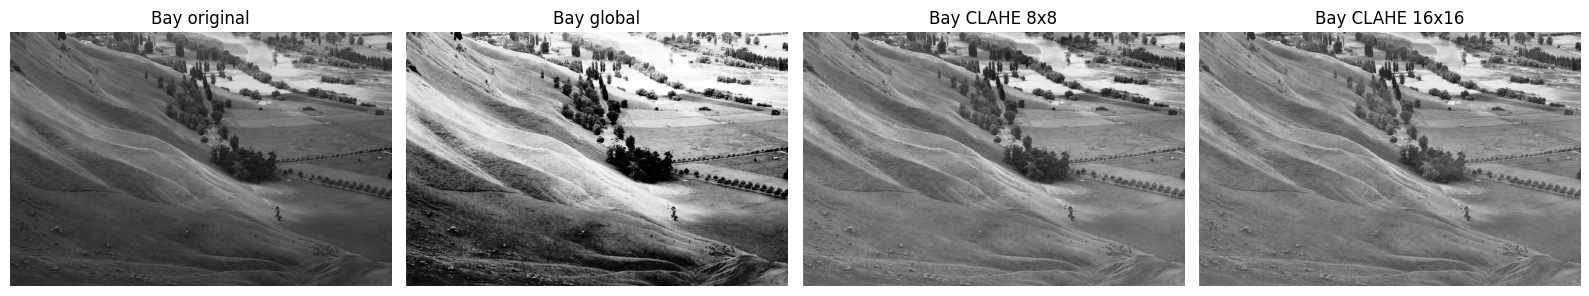

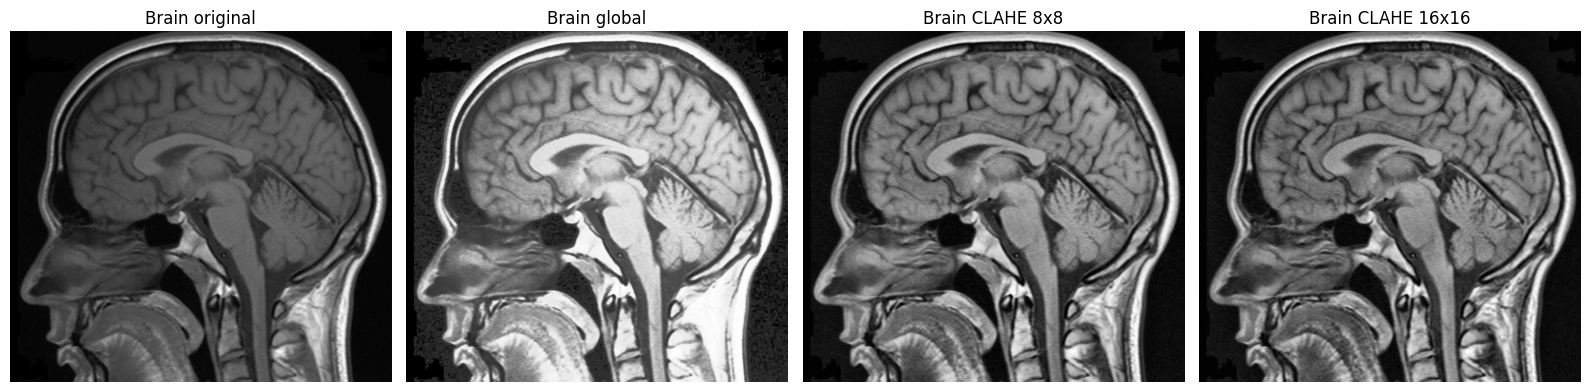

A CLAHE local costuma mostrar detalhes que a equalização global não realça.


In [10]:
globais = {nome: cv2.equalizeHist(imagem) for nome, imagem in imagens.items()}
clahe8 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe16 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
for nome in imagens:
    mostrar([(f'{nome} original', imagens[nome]), (f'{nome} global', globais[nome]), (f'{nome} CLAHE 8x8', clahe8.apply(imagens[nome])), (f'{nome} CLAHE 16x16', clahe16.apply(imagens[nome]))], colunas=4)
print('A CLAHE local costuma mostrar detalhes que a equalização global não realça.')

## 11) Canais RGB da imagem Balloons
O OpenCV lê imagens coloridas na ordem BGR. Os canais são exibidos separadamente em tons de cinza.

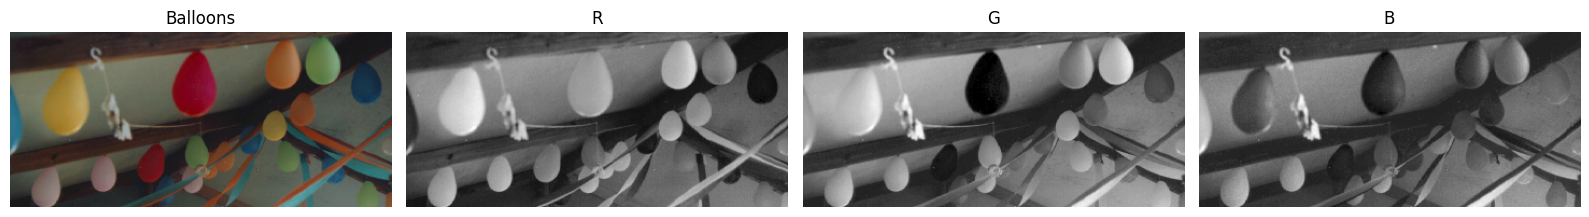

In [11]:
balloons = ler('balloons.tif')
b, g, r = cv2.split(balloons)
mostrar([('Balloons', balloons), ('R', r), ('G', g), ('B', b)])

## 12) Conversão da Balloons para cinza
A média dá o mesmo peso para os três canais. A conversão padrão do OpenCV usa pesos diferentes, dando maior peso ao verde.

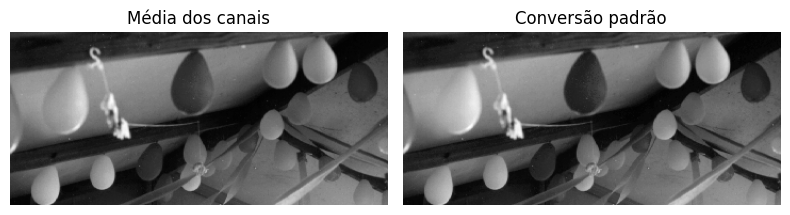

In [12]:
media_cinza = np.uint8(np.mean(balloons, axis=2))
cinza_padrao = cv2.cvtColor(balloons, cv2.COLOR_BGR2GRAY)
mostrar([('Média dos canais', media_cinza), ('Conversão padrão', cinza_padrao)], colunas=2)

## 13) Segmentação da cor vermelha
A máscara combina o limiar global da imagem cinza com a comparação entre os canais. Ainda podem passar sombras, reflexos e tons alaranjados.

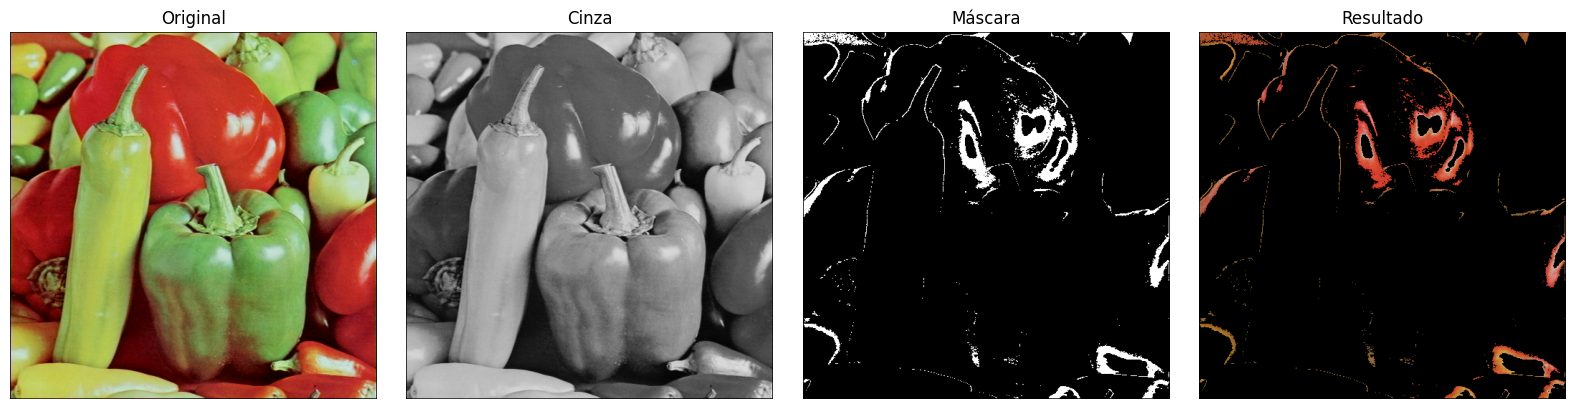

In [13]:
peppers = ler('peppers3.tif')
cinza = cv2.cvtColor(peppers, cv2.COLOR_BGR2GRAY)
_, limiar = cv2.threshold(cinza, 100, 255, cv2.THRESH_BINARY)
b, g, r = cv2.split(peppers)
vermelho = ((r > g * 1.25) & (r > b * 1.25) & (limiar > 0)).astype(np.uint8) * 255
resultado = cv2.bitwise_and(peppers, peppers, mask=vermelho)
mostrar([('Original', peppers), ('Cinza', cinza), ('Máscara', vermelho), ('Resultado', resultado)])

## 14) Otsu e limiarização local
Otsu escolhe um único limiar. A limiarização adaptativa calcula um limiar para cada vizinhança e funciona melhor quando a iluminação não é uniforme.

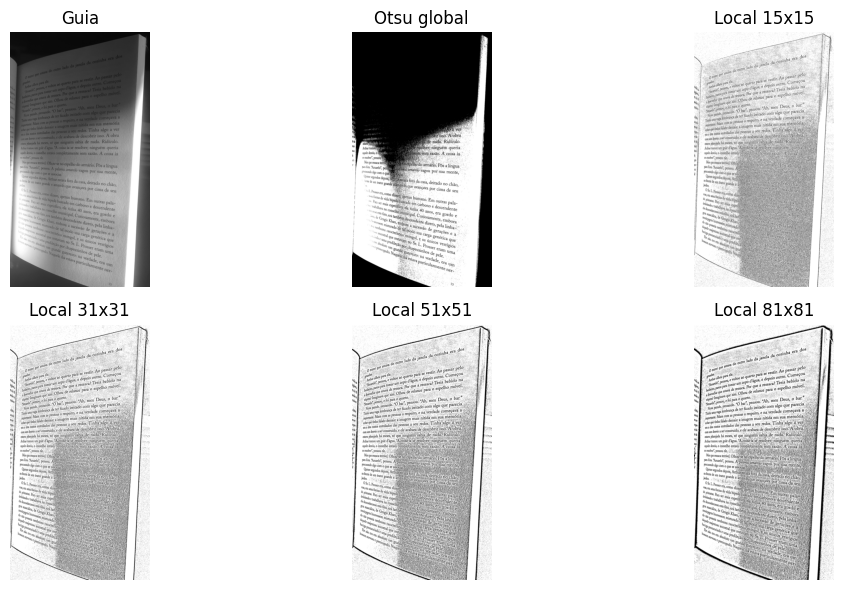

Janelas intermediárias, como 31x31 ou 51x51, normalmente equilibram detalhe e estabilidade.


In [14]:
guia = cv2.cvtColor(ler('guia.jpg'), cv2.COLOR_BGR2GRAY)
_, otsu = cv2.threshold(guia, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
locais = []
for janela in [15, 31, 51, 81]:
    local = cv2.adaptiveThreshold(guia, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, janela, 5)
    locais.append((f'Local {janela}x{janela}', local))
mostrar([('Guia', guia), ('Otsu global', otsu)] + locais, colunas=3, tamanho=(4, 3))
print('Janelas intermediárias, como 31x31 ou 51x51, normalmente equilibram detalhe e estabilidade.')